# Python Lesson 40: Gradient

**Concept page:** `wiki/concepts/gradient.md` · **Area:** calculus

**You will be able to:**
- assemble the gradient vector
- verify it points uphill
- find critical points with ∇f = 0

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Gradient of f = x²+y²

In [2]:
x,y=sp.symbols('x y'); f=x**2+y**2
grad=sp.Matrix([sp.diff(f,x),sp.diff(f,y)]); print(grad.T, "at (2,3):", grad.subs({x:2,y:3}).T)

Matrix([[2*x, 2*y]]) at (2,3): Matrix([[4, 6]])


## 2. Gradient field and contours

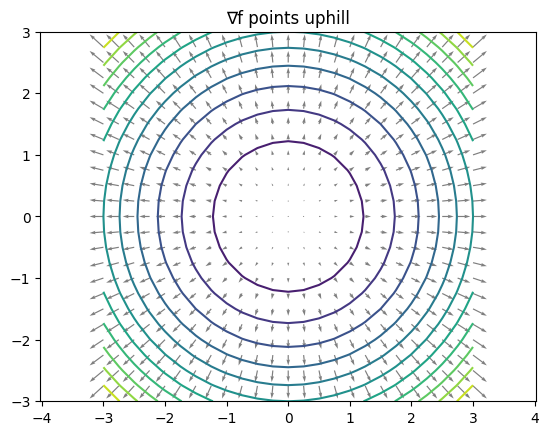

In [3]:
fn=sp.lambdify((x,y),f,'numpy'); X,Y=np.meshgrid(np.linspace(-3,3,25),np.linspace(-3,3,25))
plt.contour(X,Y,fn(X,Y),15); plt.quiver(X,Y,2*X,2*Y,alpha=.5); plt.axis('equal'); plt.title("∇f points uphill"); plt.show()

## 3. The temperature example: find critical points

In [4]:
T=85-sp.Rational(1,90)*x**2*(x-6)*y**2*(y-6)
sol=sp.solve([sp.diff(T,x),sp.diff(T,y)],[x,y],dict=True)
for s in sol:
    if all(0<=v<=6 for v in s.values()): print(s, float(T.subs(s)))

{x: 0} 85.0
{y: 0} 85.0
{x: 4, y: 0} 85.0
{x: 4, y: 4} 73.62222222222222
{x: 6, y: 6} 85.0


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
The textbooks stop at one variable; this lesson is the Coursera extension. Temperature minimum is at (4,4) with T≈73.6.

In [5]:
print(float(T.subs({x:4,y:4})))

73.62222222222222


## Exercises

**Exercise 1.** Find the gradient of f=x^2 y + y^3 at (1,2) (4, 13).

In [6]:
# your code here

**Exercise 2.** Confirm the directional derivative along ∇f is |∇f| at (1,2).

In [7]:
# your code here

## Solutions
*(Try the exercises first!)*

In [8]:
# Solution 1
x,y=sp.symbols('x y'); g=sp.Matrix([sp.diff(x**2*y+y**3,v) for v in (x,y)]); print(g.subs({x:1,y:2}).T); assert list(g.subs({x:1,y:2}))==[4,13]

Matrix([[4, 13]])


In [9]:
# Solution 2
g=np.array([4.,13.]); u=g/np.linalg.norm(g); h=1e-6; f=lambda a,b:a**2*b+b**3; d=(f(1+h*u[0],2+h*u[1])-f(1,2))/h; assert abs(d-np.linalg.norm(g))<1e-4